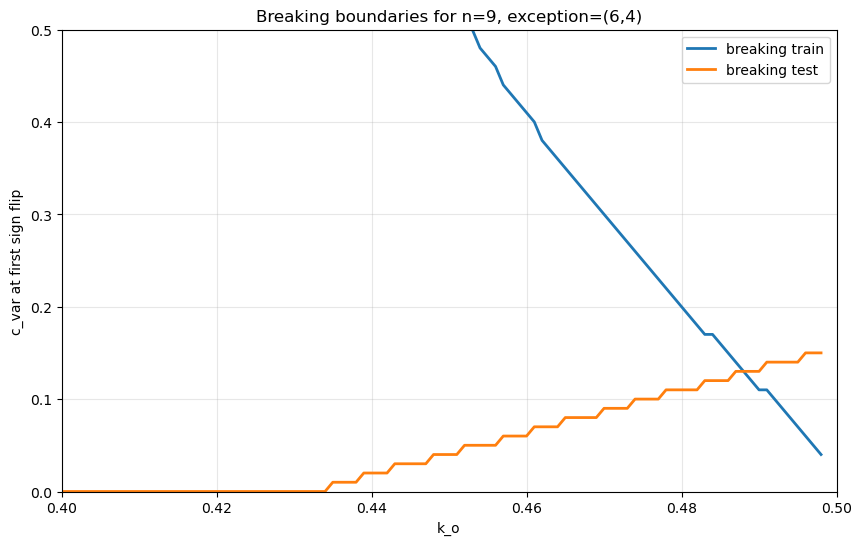

D_jp_til_part_val: 3.8919753086419786
D_jq_til_part_val: 11.961248285322377
D_jp_til_part_val: 5.18930041152264
D_jq_til_part_val: 15.948331047096508
D_jp_til_part_val: 8.216392318244182
D_jq_til_part_val: 25.25152415790281
D_jp_til_part_val: 13.982281664380455
D_jq_til_part_val: 42.97189198801006
D_jp_til_part_val: 24.408931565310215
D_jq_til_part_val: 24.408931565310215
D_jp_til_part_val: 42.97189198801006
D_jq_til_part_val: 13.982281664380455
D_jp_til_part_val: 25.25152415790281
D_jq_til_part_val: 8.216392318244182
D_jp_til_part_val: 15.948331047096508
D_jq_til_part_val: 5.18930041152264
D_jp_til_part_val: 11.961248285322377
D_jq_til_part_val: 3.8919753086419786


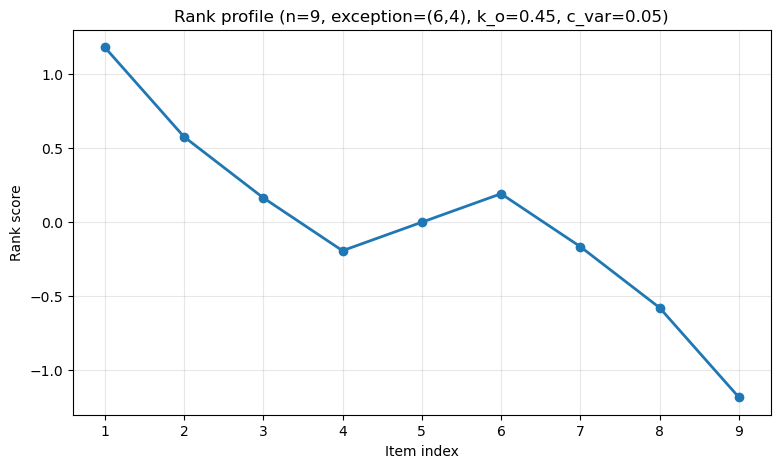

In [ ]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is on path so Ranking_exp imports reliably from this notebook.
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Ranking_exp import Ranking_exp

# Parameters: n = 9, exception at (p, q) = (6, 4)
n = 9
p, q = 6, 4
k_s, k_d = 1.0, 0.0

delta_s = k_s - k_d
k_o_vals = np.arange(0.4, 0.499, 0.001)
c_var_vals = np.arange(1e-4, 10, 0.01)
c_vals = 1.0 / (c_var_vals * delta_s)

# Critical pairs used in your original logic
test_pair = (q - 1, p)   # (3, 6)
train_pair = (q, q + 1)  # (4, 5)

breaking_reg_test = []
breaking_reg_train = []

for k_o in k_o_vals:
    # Test boundary: first c_var where margin becomes negative
    test_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*test_pair) < 0:
            test_break = c_var
            break
    breaking_reg_test.append(test_break)

    # Train boundary: first c_var where margin becomes negative
    train_break = 0.0
    for c_var, c_reg in zip(c_var_vals, c_vals):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
        if sim.f_j_k(*train_pair) < 0:
            train_break = c_var
            break
    breaking_reg_train.append(train_break)

# ---- Plot 1: phase/break diagram ----
plt.figure(figsize=(10, 6))
plt.plot(k_o_vals, breaking_reg_train, label='breaking train', linewidth=2)
plt.plot(k_o_vals, breaking_reg_test, label='breaking test', linewidth=2)
plt.title(f'Breaking boundaries for n={n}, exception=({p},{q})')
plt.xlabel('k_o')
plt.ylabel('c_var at first sign flip')
plt.xlim(0.40, 0.50)
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


D_jp_til_part_val: 27.012345679012338
D_jq_til_part_val: 243.00137174211235
D_jp_til_part_val: 63.028806584362115
D_jq_til_part_val: 567.0032007315954
D_jp_til_part_val: 183.0836762688613
D_jq_til_part_val: 1647.0092973632052
D_jp_til_part_val: 547.2501143118424
D_jq_til_part_val: 4923.02779047909
D_jp_til_part_val: 1641.083371437279
D_jq_til_part_val: 1641.083371437279
D_jp_til_part_val: 4923.02779047909
D_jq_til_part_val: 547.2501143118424
D_jp_til_part_val: 1647.0092973632052
D_jq_til_part_val: 183.0836762688613
D_jp_til_part_val: 567.0032007315954
D_jq_til_part_val: 63.028806584362115
D_jp_til_part_val: 243.00137174211235
D_jq_til_part_val: 27.012345679012338


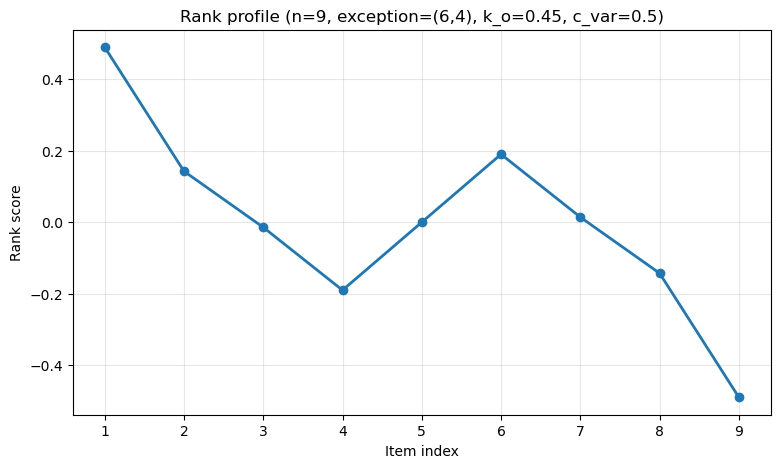

In [6]:

# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = 0.5
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank_analytic()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

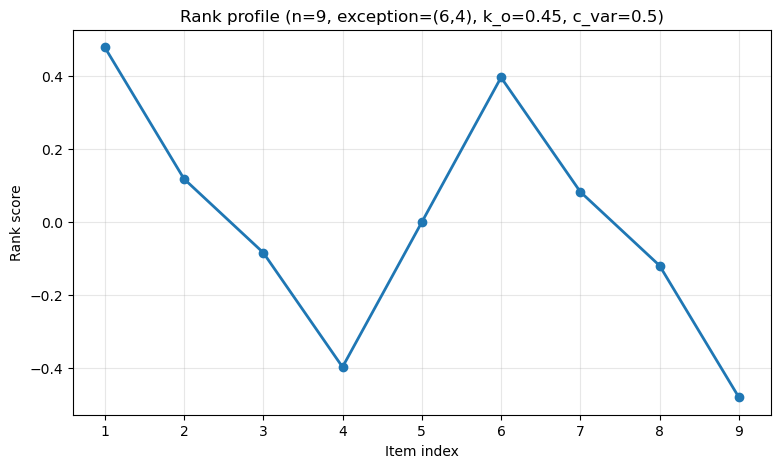

In [5]:


# ---- Plot 2: ranking profile at one sample (k_o, c_var) ----
k_o_demo = 0.45
c_var_demo = .5
c_reg_demo = 1.0 / (c_var_demo * delta_s)

sim_demo = Ranking_exp(n=n, k_o=k_o_demo, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_demo)
ranks_demo = sim_demo.calc_rank()

plt.figure(figsize=(9, 5))
idx = np.arange(1, n + 1)
plt.plot(idx, ranks_demo, marker='o', linewidth=2)
plt.title(f'Rank profile (n={n}, exception=({p},{q}), k_o={k_o_demo}, c_var={c_var_demo})')
plt.xlabel('Item index')
plt.ylabel('Rank score')
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
import numpy as np
from Ranking_exp import Ranking_exp

# try a few different parameter settings
configs = [
    dict(n=7, p=2, q=5, k_o=0.1, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=2.0),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=7, p=3, q=5, k_o=0.2, k_s=1.0, k_d=0.0, c_reg=10.0),
]

for cfg in configs:
    sim = Ranking_exp(**cfg)
    ra = sim.calc_rank_analytic()
    r  = sim.calc_rank()
    print(f"cfg={cfg}")
    print(f"  calc_rank_analytic: {np.round(ra, 5)}")
    print(f"  calc_rank         : {np.round(r,  5)}")
    print(f"  max |diff|        : {np.max(np.abs(ra - r)):.3e}")
    print()

D_jp_til_part_val: 258988.56171640666
D_jq_til_part_val: 267.00079250077493
D_jp_til_part_val: 2330899.645333277
D_jq_til_part_val: 2403.0098025148995
D_jp_til_part_val: 235468.44119616091
D_jq_til_part_val: 23763.121262746237
D_jp_til_part_val: 23787.121312746287
D_jq_til_part_val: 235228.4404561603
D_jp_til_part_val: 2403.0098025148995
D_jq_til_part_val: 2328523.635583259
D_jp_til_part_val: 243.00074250075002
D_jq_til_part_val: 235468.44119616091
D_jp_til_part_val: 27.000052500025003
D_jq_til_part_val: 26163.131062761142
cfg={'n': 7, 'p': 2, 'q': 5, 'k_o': 0.1, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  calc_rank_analytic: [ 1.1232e-01  1.0840e-02  1.0900e-03  5.0000e-05 -6.2000e-04 -1.1300e-02
 -1.1237e-01]
  calc_rank         : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]
  max |diff|        : 8.422e-02

D_jp_til_part_val: 27.012345679012338
D_jq_til_part_val: 243.00137174211235
D_jp_til_part_val: 63.028806584362115
D_jq_til_part_val: 567.0032007315954
D_jp_t

In [7]:
import numpy as np
from Ranking_exp import Ranking_exp

def ground_truth_rank(sim):
    """Compute the true r_j directly from the solved dual coefficients."""
    _ = sim.calc_rank()            # populates sim.a_exp
    n, p, q = sim.n, sim.p, sim.q
    ap = sim.alpha_prime

    a_exp = sim.a_exp
    b = {i: a_exp[i-1] for i in range(1, n)}   # b_1 .. b_{n-1}
    b[0] = 0.0
    b[n] = 0.0
    c = a_exp[2*(n-1)]                         # the exception coefficient c

    def delta(i, j): return 1.0 if i == j else 0.0

    ranks = np.zeros(n)
    for j in range(1, n+1):
        ranks[j-1] = ap * (b[j] - b[j-1]) + ap * c * (delta(j, p) - delta(j, q))
    return ranks, c

configs = [
    dict(n=7, p=2, q=5, k_o=0.1,  k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=2.0),
    dict(n=9, p=6, q=4, k_o=0.45, k_s=1.0, k_d=0.0, c_reg=1e6),
    dict(n=7, p=3, q=5, k_o=0.2,  k_s=1.0, k_d=0.0, c_reg=10.0),
]

for cfg in configs:
    sim = Ranking_exp(**cfg)
    truth, c_true = ground_truth_rank(sim)
    ra = sim.calc_rank_analytic()
    r  = sim.calc_rank()
    print(f"cfg={cfg}")
    print(f"  ground truth       : {np.round(truth, 5)}   (c_true = {c_true:.5f})")
    print(f"  calc_rank          : {np.round(r,     5)}   max|err|={np.max(np.abs(r  - truth)):.2e}")
    print(f"  calc_rank_analytic : {np.round(ra,    5)}   max|err|={np.max(np.abs(ra - truth)):.2e}")
    print()

D_jp_til_part_val: 258988.56171640666
D_jq_til_part_val: 267.00079250077493
D_jp_til_part_val: 2330899.645333277
D_jq_til_part_val: 2403.0098025148995
D_jp_til_part_val: 235468.44119616091
D_jq_til_part_val: 23763.121262746237
D_jp_til_part_val: 23787.121312746287
D_jq_til_part_val: 235228.4404561603
D_jp_til_part_val: 2403.0098025148995
D_jq_til_part_val: 2328523.635583259
D_jp_til_part_val: 243.00074250075002
D_jq_til_part_val: 235468.44119616091
D_jp_til_part_val: 27.000052500025003
D_jq_til_part_val: 26163.131062761142
cfg={'n': 7, 'p': 2, 'q': 5, 'k_o': 0.1, 'k_s': 1.0, 'k_d': 0.0, 'c_reg': 1000000.0}
  ground truth       : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]   (c_true = 1.02523)
  calc_rank          : [ 0.12167  0.09506  0.00875 -0.0076  -0.08476 -0.01981 -0.11331]   max|err|=8.69e-08
  calc_rank_analytic : [ 1.1232e-01  1.0840e-02  1.0900e-03  5.0000e-05 -6.2000e-04 -1.1300e-02
 -1.1237e-01]   max|err|=8.42e-02

D_jp_til_part_val: 27.012345679012338
